X shape: (38993, 14, 13)
y shape: (38993,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 14, 128)        │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,225 (360.25 KB)

 Trainable params: 92,225 (360.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - loss: 8.3418e-04 - val_loss: 5.3788e-04
Epoch 2/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 1.2411e-04 - val_loss: 3.8326e-04
Epoch 3/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 8.5765e-05 - val_loss: 3.6073e-04
Epoch 4/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 6.9378e-05 - val_loss: 3.2120e-04
Epoch 5/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 5.9365e-05 - val_loss: 3.0414e-04
Epoch 6/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 5.3750e-05 - val_loss: 2.7700e-04
Epoch 7/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 5.0473e-05 - val_loss: 2.7389e-04
Epoch 8/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - loss: 4.7165e-05 - val_loss: 2.5458e-04
Epoch 9/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - loss: 4.3764e-05 - val_loss: 2.6519e-04
Epoch 10/100
780/780 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 4.2237e-05 - val_loss: 2.5657e-04
Epoch 11/100
780/780 ━━━━━━━━

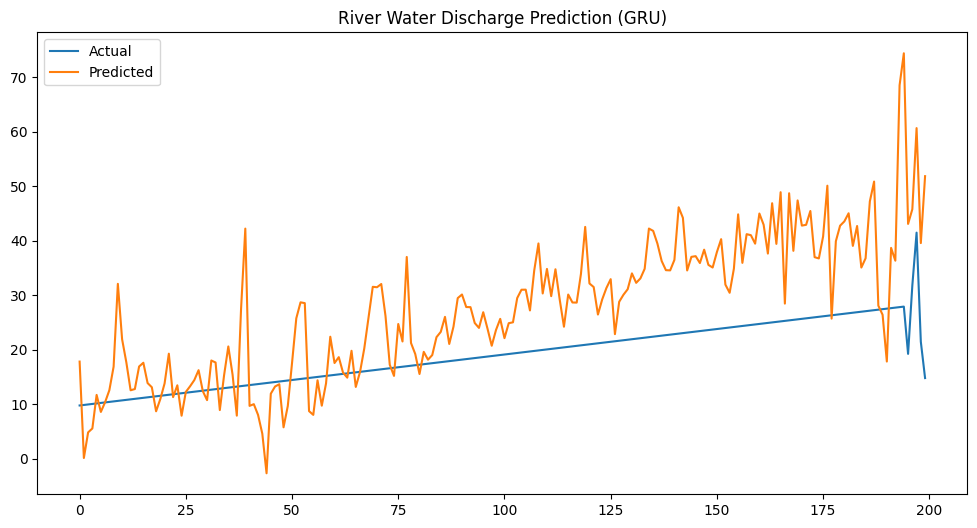

In [2]:
# ================================
# 1️⃣ Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ================================
# 2️⃣ Load Excel Dataset
# ================================
df = pd.read_excel("godavari_data.xlsx")

# ================================
# 3️⃣ Preprocessing
# ================================

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(['station_id', 'date']).reset_index(drop=True)

# Replace 0 with NaN ONLY for these columns
df['River Water Discharge'] = df['River Water Discharge'].replace(0, np.nan)
df['River Water Level'] = df['River Water Level'].replace(0, np.nan)

# ✅ FIXED: Use transform instead of apply
df['River Water Discharge'] = df.groupby('station_id')['River Water Discharge'] \
                                 .transform(lambda x: x.interpolate())

df['River Water Level'] = df.groupby('station_id')['River Water Level'] \
                             .transform(lambda x: x.interpolate())

# Drop remaining NaN if any
df = df.dropna().reset_index(drop=True)

# Drop non-numeric column
df = df.drop(columns=['station_name'])

# ================================
# 4️⃣ Feature Selection
# ================================

features = [
    'doy',
    'T2M',
    'RH2M',
    'PS',
    'WS2M',
    'GWETTOP',
    'GWETROOT',
    'GWETPROF',
    'rain',
    'tmin',
    'tmax',
    'River Water Level'
]

target = 'River Water Discharge'

df_model = df[features + [target]]

# ================================
# 5️⃣ Scaling
# ================================

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)
scaled_df = pd.DataFrame(scaled_data, columns=features + [target])

# ================================
# 6️⃣ Station-wise Sequence Creation
# ================================

def create_sequences_stationwise(original_df, scaled_array, sequence_length=14):
    X = []
    y = []

    stations = original_df['station_id'].unique()
    start_index = 0

    for station in stations:
        station_data = original_df[original_df['station_id'] == station]
        length = len(station_data)

        end_index = start_index + length
        station_scaled = scaled_array[start_index:end_index]

        for i in range(sequence_length, len(station_scaled)):
            X.append(station_scaled[i-sequence_length:i])
            y.append(station_scaled[i, -1])

        start_index = end_index

    return np.array(X), np.array(y)


sequence_length = 14
X, y = create_sequences_stationwise(df, scaled_df.values, sequence_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ================================
# 7️⃣ Train Test Split
# ================================

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ================================
# 8️⃣ Build GRU Model
# ================================

model = Sequential()

model.add(GRU(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(GRU(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

# ================================
# 9️⃣ Train Model
# ================================

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 🔟 Predictions
# ================================

y_pred = model.predict(X_test)

# ================================
# 1️⃣1️⃣ Inverse Scaling
# ================================

temp = np.zeros((len(y_pred), len(features)+1))
temp[:, -1] = y_pred.flatten()
y_pred_inverse = scaler.inverse_transform(temp)[:, -1]

temp2 = np.zeros((len(y_test), len(features)+1))
temp2[:, -1] = y_test
y_test_inverse = scaler.inverse_transform(temp2)[:, -1]

# ================================
# 1️⃣2️⃣ Evaluation
# ================================

rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
r2 = r2_score(y_test_inverse, y_pred_inverse)

smape = 100 * np.mean(
    2 * np.abs(y_pred_inverse - y_test_inverse) /
    (np.abs(y_test_inverse) + np.abs(y_pred_inverse) + 1e-10)
)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("SMAPE (%):", smape)

# ================================
# 1️⃣3️⃣ Plot Results
# ================================

plt.figure(figsize=(12,6))
plt.plot(y_test_inverse[:200], label="Actual")
plt.plot(y_pred_inverse[:200], label="Predicted")
plt.legend()
plt.title("River Water Discharge Prediction (GRU)")
plt.show()